## 初期設定：計算に必要なライブラリのインストール

pip install EMD-signal

pip install xlsxwriter

## ライブラリの読み込み

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.fft import rfft, rfftfreq, irfft
from pathlib import Path

## 1. データの読み込み

In [26]:
# 入力ファイル名
file_name_input = 'input_data/0930_room_2.xlsx'

# 出力ファイル名
file_name_output = "output_data/harmonic_analysis_results_indoor_measurement_temp.xlsx"
file_name_output_fft = "output_data/harmonic_analysis_results_fft_indoor_measurement_temp.xlsx"

In [27]:
# データの読み込み
df = pd.read_excel(file_name_input, header=[1,1], index_col=0)

In [28]:
# 分析するデータの選択
target_data = df['temp'].values
td = pd.Timedelta(df.index[1] - df.index[0])
sampling_rate = td.total_seconds()# サンプリング間隔（秒）

## 2. フーリエ変換(FFT)

### 2.1 フーリエ変換の実行

In [29]:
# target_data を1次元にして扱う
target_array = target_data.flatten()  # または reshape(-1)

# フーリエ変換の実行
fft_result = rfft(target_array)  # flatten()で1次元化
freqs = rfftfreq(len(target_data), d=sampling_rate)

# 振幅と位相を計算
amplitudes = np.abs(fft_result) / len(target_data)
phases = np.angle(fft_result)

# --- 逆フーリエ変換 ---
reconstructed = irfft(fft_result)  # 元の波形の再構成

### 2.2 フーリエ変換の結果の出力

' plt.subplot(2, 1, 2)\nplt.plot(freqs, phases, label="Phase Spectrum", color="orange")\nplt.title("Phase Spectrum from Fourier Transform")\nplt.xlabel("Frequency (Hz)")\nplt.ylabel("Phase (radians)")\nplt.grid(True)\nplt.legend()\n\nplt.tight_layout()\nplt.show() '

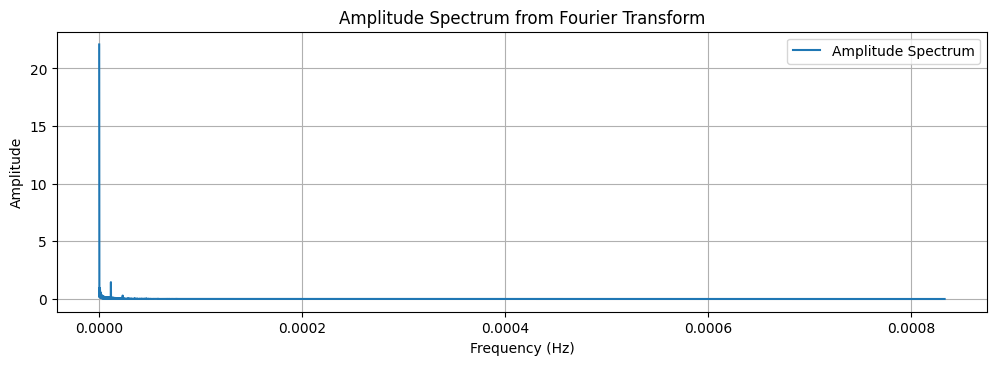

In [30]:
# グラフ化
plt.figure(figsize=(12, 8))

# 振幅スペクトル
plt.subplot(2, 1, 1)
plt.plot(freqs, amplitudes, label="Amplitude Spectrum")
plt.title("Amplitude Spectrum from Fourier Transform")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# 位相スペクトル
""" plt.subplot(2, 1, 2)
plt.plot(freqs, phases, label="Phase Spectrum", color="orange")
plt.title("Phase Spectrum from Fourier Transform")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show() """


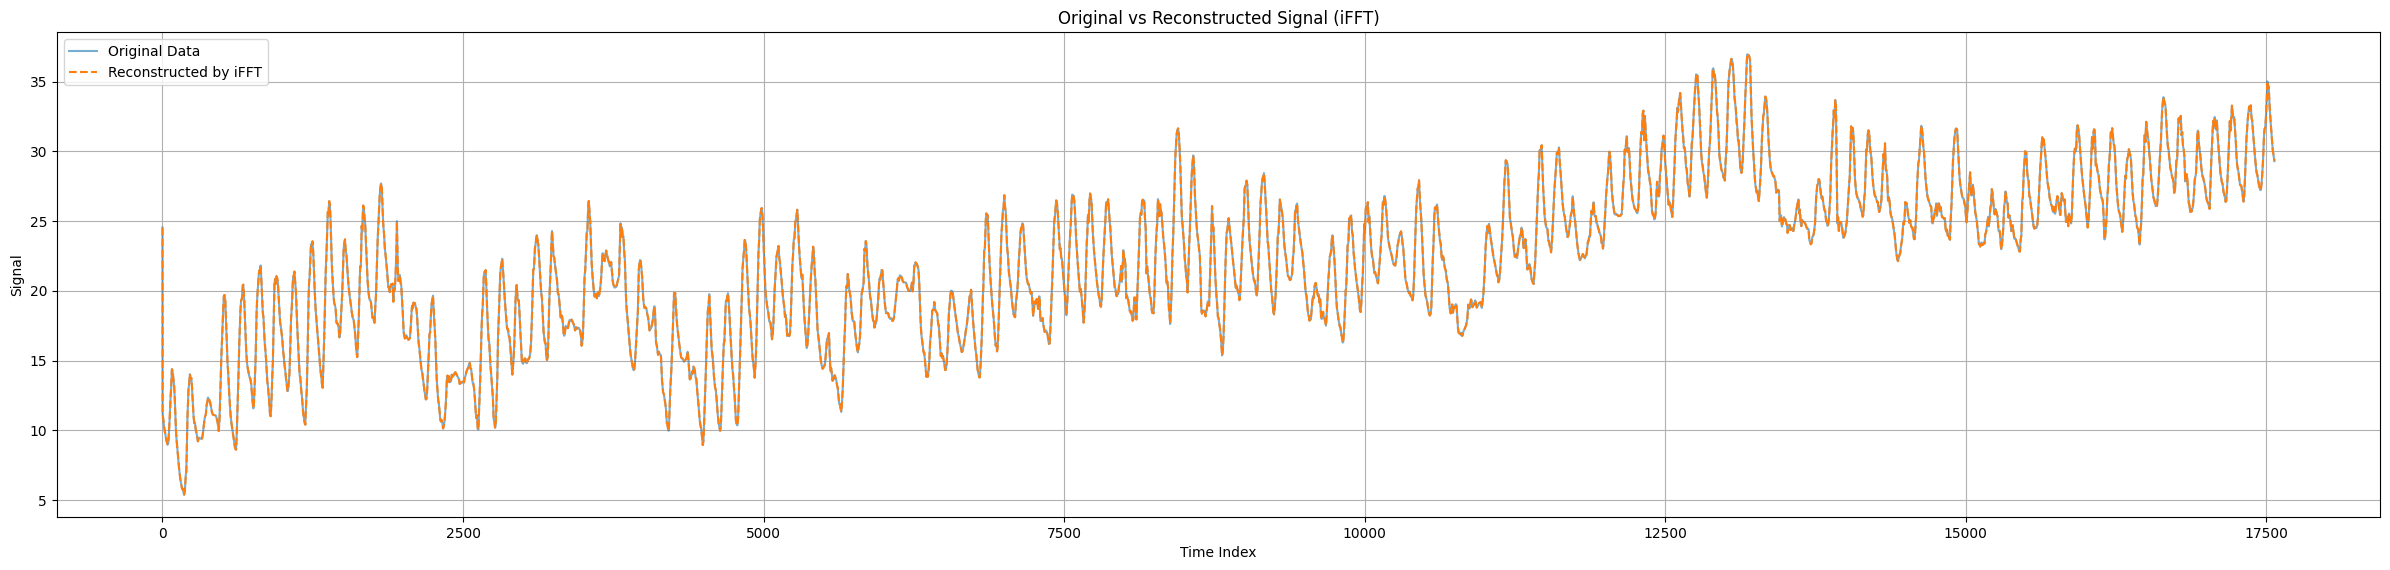

In [31]:
# グラフの作成（大きめに設定）
plt.figure(figsize=(24, 16))  # ← サイズを拡大しました（横16, 縦12）

# --- グラフ：元データと再構成波形の比較 ---
plt.subplot(3, 1, 2)
plt.plot(target_data.flatten(), label="Original Data", alpha=0.6)
plt.plot(reconstructed, label="Reconstructed by iFFT", linestyle="--")
plt.title("Original vs Reconstructed Signal (iFFT)")
plt.xlabel("Time Index")
plt.ylabel("Signal")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# 時間軸
t = np.arange(len(target_array)) * sampling_rate
t_days = t / 86400

# === Excel出力の準備 ===

# 周波数スペクトルシート
periods = np.where(freqs != 0, 1 / freqs / 86400, np.nan)  # 周期（日）
fourier_df = pd.DataFrame({
    "Frequency (Hz)": freqs,
    "Period (Day)": periods,
    "Amplitude": amplitudes,
    "Phase (radians)": phases
})

# 最小の長さに揃える
min_len = min(len(t), len(target_array), len(reconstructed))

# 各配列を揃える
t = t[:min_len]
t_days = t_days[:min_len]
target_array = target_array[:min_len]
reconstructed = reconstructed[:min_len]

# 時系列波形をDataFrameに（長さを合わせる）
waveform_df = pd.DataFrame({
    "Time [s]": t,
    "Time [day]": t_days,
    "Original": target_array,
    "Reconstructed": reconstructed
})

# === Excel出力 ===
with pd.ExcelWriter(file_name_output_fft, engine="xlsxwriter") as writer:
    fourier_df.to_excel(writer, index=False, sheet_name="Fourier Spectrum")
    waveform_df.to_excel(writer, index=False, sheet_name="Waveforms")

print(f"✅ Fourierスペクトルと再構成波形を '{file_name_output}' に保存しました。")

/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_72494/2820053657.py:8: RuntimeWarning: divide by zero encountered in divide
  periods = np.where(freqs != 0, 1 / freqs / 86400, np.nan)  # 周期（日）


✅ Fourierスペクトルと再構成波形を 'output_data/harmonic_analysis_results_indoor_measurement_temp.xlsx' に保存しました。


## 3. ハーモニック回帰

### 3.1 事前分析

In [33]:
# Amplitudeが大きい順にソートし、上位11個を抽出
top_n = 51
indices = np.argsort(amplitudes)[-top_n:][::-1]  # 振幅の大きい順にインデックスを取得
top_amplitudes = amplitudes[indices]
top_frequencies = freqs[indices]

# 結果を表示
for i, (freq, amp) in enumerate(zip(top_frequencies, top_amplitudes), 1):
    print(f"Rank {i}: Frequency = {1/freq/24/60/60:.1f} Day, Amplitude = {amp:.6f}")

Rank 1: Frequency = inf Day, Amplitude = 22.083338
Rank 2: Frequency = 122.0 Day, Amplitude = 2.622549
Rank 3: Frequency = 1.0 Day, Amplitude = 1.460377
Rank 4: Frequency = 30.5 Day, Amplitude = 0.970388
Rank 5: Frequency = 61.0 Day, Amplitude = 0.910456
Rank 6: Frequency = 15.2 Day, Amplitude = 0.835446
Rank 7: Frequency = 13.6 Day, Amplitude = 0.793260
Rank 8: Frequency = 24.4 Day, Amplitude = 0.767708
Rank 9: Frequency = 7.2 Day, Amplitude = 0.565814
Rank 10: Frequency = 9.4 Day, Amplitude = 0.503331
Rank 11: Frequency = 7.6 Day, Amplitude = 0.475205
Rank 12: Frequency = 6.1 Day, Amplitude = 0.420282
Rank 13: Frequency = 20.3 Day, Amplitude = 0.416289
Rank 14: Frequency = 12.2 Day, Amplitude = 0.399783
Rank 15: Frequency = 5.5 Day, Amplitude = 0.379057
Rank 16: Frequency = 17.4 Day, Amplitude = 0.340108
Rank 17: Frequency = 0.5 Day, Amplitude = 0.297720
Rank 18: Frequency = 10.2 Day, Amplitude = 0.278620
Rank 19: Frequency = 3.7 Day, Amplitude = 0.244502
Rank 20: Frequency = 4.5 Day

/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_72494/3377210517.py:9: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"Rank {i}: Frequency = {1/freq/24/60/60:.1f} Day, Amplitude = {amp:.6f}")


### 3.2 最小二乗法を用いた回帰

In [34]:
# サンプリング情報
dt = sampling_rate  # 秒（10分）
N = len(target_data)  # データ数
t = np.arange(N) * dt  # 時間軸（秒単位）

# --- 使いたい周波数を定義（周期：1日・2日など） ---
# 周波数（Hz）＝ 1 / 周期（秒）
frequencies = {
    #f"{round(1 / freq / 24 / 60 / 60, 2)} Day": amp
    f"{round(1 / freq / 24 / 60 / 60, 2)} Day": freq
    for freq in top_frequencies
}

# 回帰用デザイン行列の作成
X = pd.DataFrame({"Intercept": np.ones(N)})
for label, freq in frequencies.items():
    X[f"cos_{label}"] = np.cos(2 * np.pi * freq * t)
    X[f"sin_{label}"] = np.sin(2 * np.pi * freq * t)

# 回帰モデルの学習（最小二乗法）
model = sm.OLS(target_data.flatten(), X).fit()

# 再構成（全体）
y_fit_total = model.predict(X)


/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_72494/804253887.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  f"{round(1 / freq / 24 / 60 / 60, 2)} Day": freq
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_72494/804253887.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"sin_{label}"] = np.sin(2 * np.pi * freq * t)
/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_72494/804253887.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f"cos_{label}"] = np.cos(2 * np.pi

### 3.3 グラフへの描画

/var/folders/2k/k4_5r8jj2kb_bhlj9_bgqtwh0000gn/T/ipykernel_72494/2859029811.py:26: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


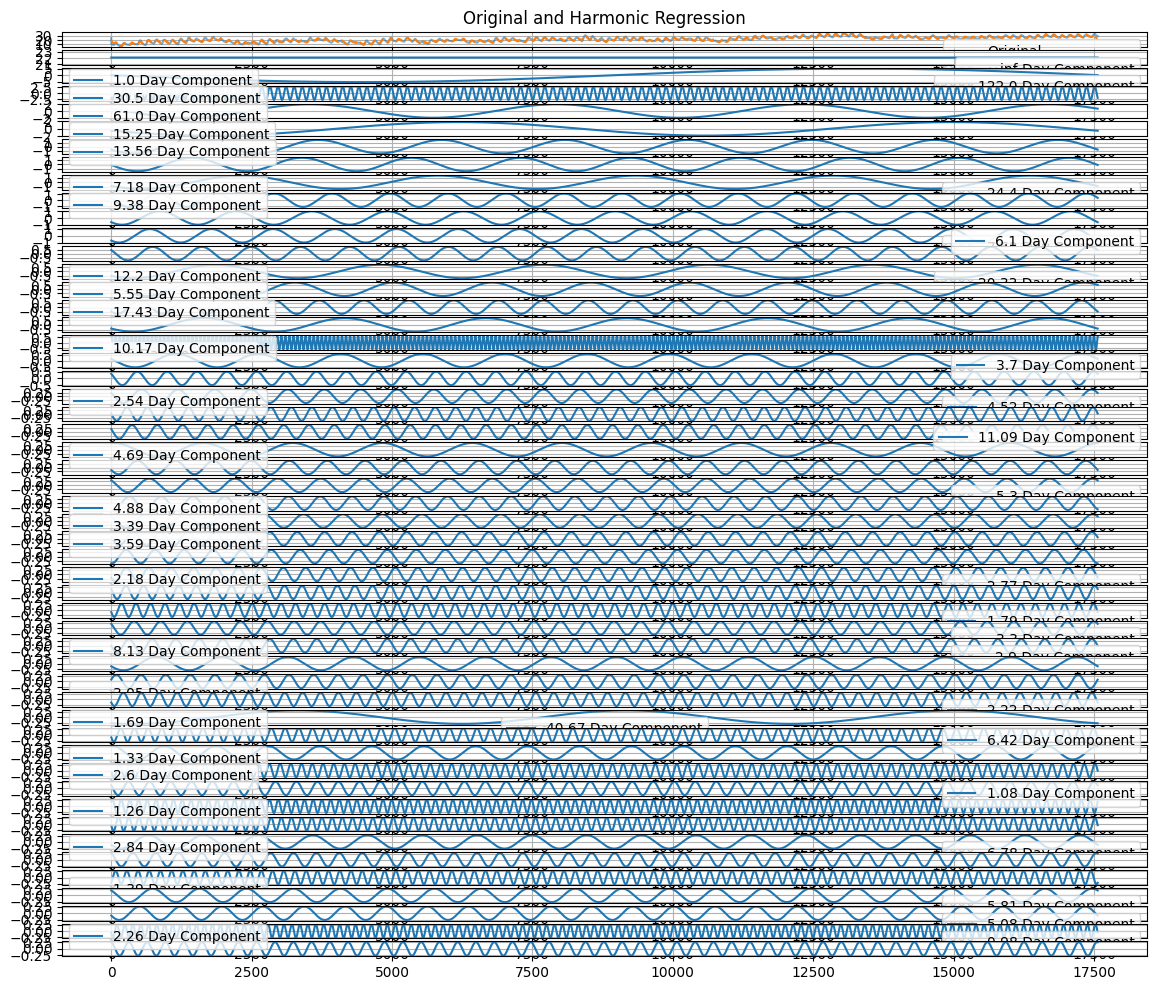

In [35]:
# --- 各成分の波形を個別にプロット ---
plt.figure(figsize=(14, 12))

# オリジナル vs 回帰再構成
plt.subplot(len(frequencies) + 1, 1, 1)
plt.plot(target_data.flatten(), label="Original", alpha=0.6)
plt.plot(y_fit_total, label="Harmonic Regression", linestyle="--")
plt.title("Original and Harmonic Regression")
plt.legend()
plt.grid(True)

# 各周波数成分を個別にプロット
for i, (label, freq) in enumerate(frequencies.items(), start=2):
    if freq == 0.0:
        # 周波数0（定数成分）は amplitudes[0]の値をそのまま使って平坦な直線を描く
        component = np.full_like(t, amplitudes[0])
    else:
        component = (model.params[f"cos_{label}"] * np.cos(2 * np.pi * freq * t) +
                     model.params[f"sin_{label}"] * np.sin(2 * np.pi * freq * t))
    
    plt.subplot(len(frequencies) + 1, 1, i)
    plt.plot(component, label=f"{label} Component")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


### 3.4 Excel ファイルへの出力

In [36]:
# --- 各周波数成分の波形（回帰による再構成） ------------
component_df = pd.DataFrame({"Time [s]": t, "Original Data": target_data.flatten()})
for label, freq in frequencies.items():
    cos_wave = model.params[f"cos_{label}"] * np.cos(2 * np.pi * freq * t)
    sin_wave = model.params[f"sin_{label}"] * np.sin(2 * np.pi * freq * t)

    if freq == 0.0:
        # 周波数0（定数成分）は amplitudes[0]の値をそのまま使って平坦な直線を描く
        component_df[f"{label}_component"] = amplitudes[0]
    else:
        component_df[f"{label}_component"] = cos_wave + sin_wave
        
    #component_df[f"{label}_component"] = cos_wave + sin_wave

# ----------- シート3: 回帰係数、振幅、位相の計算 ------------
coeffs = []
for label, freq in frequencies.items():
    cos_coeff = model.params[f"cos_{label}"]
    sin_coeff = model.params[f"sin_{label}"]
    
    # 振幅と位相を計算
    if freq == 0.0:
        amplitude = amplitudes[0]
    else:
        amplitude = np.sqrt(cos_coeff**2 + sin_coeff**2)

    phase = np.arctan2(sin_coeff, cos_coeff)
    
    coeffs.append({
        "Component": label,
        "cos_coeff": cos_coeff,
        "sin_coeff": sin_coeff,
        "Amplitude": amplitude,
        "Phase (radians)": phase
    })

coeff_df = pd.DataFrame(coeffs)

# ----------- Excelファイルにまとめて出力 ------------
output_excel = file_name_output # 出力ファイル名
with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    # シート1: フーリエスペクトル
    fft_df = pd.DataFrame({
        "Frequency (Hz)": freqs,
        "Amplitude": amplitudes,
        "Phase (radians)": phases
    })
    fft_df.to_excel(writer, index=False, sheet_name="Fourier Spectrum")
    
    # シート2: 各周波数成分の波形（回帰による再構成）
    component_df.to_excel(writer, index=False, sheet_name="Harmonic Components")
    
    # シート3: 回帰係数、振幅、位相
    coeff_df.to_excel(writer, index=False, sheet_name="Harmonic Coefficients")

print(f"✅ ハーモニック回帰およびフーリエ分析の結果を '{output_excel}' に保存しました。")


✅ ハーモニック回帰およびフーリエ分析の結果を 'output_data/harmonic_analysis_results_indoor_measurement_temp.xlsx' に保存しました。
